In [2]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'C:\\Users\\marye\\Downloads\\Business_Case (1).csv'
data = pd.read_csv(file_path, delimiter=';')

data

,session_id,platform,open_at,user_id,country,ab_cohort_id,segment_id,session_length,session_number_,publisher_revenue,fs_shown,rv_shown,game_count,offline_game_count,acquired_at,segment_name,ab_name,ab_cohort_name
0,e058d9e3-ea0c-4d16-a36e-3e9ed3840457,android,2020-02-09 11:27:45.717000,3675ed02-ea35-4f01-8375-2ee48b06ac5c,TN,790,783,36,5,0.000010,0,0,1,0,2020-02-08 10:35:38.630000,android_new_users,ab-test_android,gameTune
1,6b9d2f3d-fe82-45fb-9c67-9408934393b1,android,2020-02-09 11:04:38.491000,3675ed02-ea35-4f01-8375-2ee48b06ac5c,TN,790,783,158,4,0.000110,1,0,1,0,2020-02-08 10:35:38.630000,android_new_users,ab-test_android,gameTune
2,bdf0bb00-9241-4e2a-969b-c55267befa76,android,2020-02-09 10:59:48.496000,3675ed02-ea35-4f01-8375-2ee48b06ac5c,TN,790,783,90,3,0.000020,1,0,0,0,2020-02-08 10:35:38.630000,android_new_users,ab-test_android,gameTune
3,79ea0b6c-ea19-480d-b6b4-60acbef70241,android,2020-02-05 12:15:02.907000,51ea5d8d-9b28-4111-ab23-40961dc43321,AE,789,783,517,1,0.055515,7,0,4,0,2020-02-05 12:15:02.907000,android_new_users,ab-test_android,xxHigh
4,f5f1f67f-ac44-45ba-9650-07b8081d897f,android,2020-02-07 06:03:13.014000,ecfbf8db-300f-4ceb-a533-47d9bf0c9fc7,AE,790,783,385,1,0.014300,2,0,5,0,2020-02-07 06:03:13.014000,android_new_users,ab-test_android,gameTune
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372829,8be26aa7-be0c-45c4-b55e-935f5d35cec4,ios,2020-02-17 07:52:06.131000,af301d08-dd5a-42c5-b9e8-b9115073ec2d,US,796,792,91,1,0.034047,1,0,2,0,2020-02-17 07:52:06.131000,ios_new_users,ab-test_ios,control
372830,f43b7940-7b04-43d2-97e7-e84679303bcf,ios,2020-02-17 04:38:01.166000,74b69fd3-5fbb-4de2-9e1d-edda05bf70de,US,799,792,452,1,0.104641,5,0,4,0,2020-02-17 04:38:01.166000,ios_new_users,ab-test_ios,gameTune
372831,cd5b92af-a4ec-4a63-ba15-018c461f194d,ios,2020-02-17 05:37:26.929000,b7c1d4da-6803-4f22-b7d7-3170f8f0ecd3,US,797,792,134,3,0.023911,1,0,1,0,2020-02-17 00:51:04.120000,ios_new_users,ab-test_ios,xHigh
372832,e094a2e7-598d-4686-b445-3f9196ff7936,ios,2020-02-17 02:25:25.366000,b7c1d4da-6803-4f22-b7d7-3170f8f0ecd3,US,797,792,271,2,0.104209,5,0,3,0,2020-02-17 00:51:04.120000,ios_new_users,ab-test_ios,xHigh


In [3]:
file_path = r'C:\Users\marye\Downloads\Business_Case (1).csv' 
data_demo = pd.read_csv(file_path, delimiter=';')

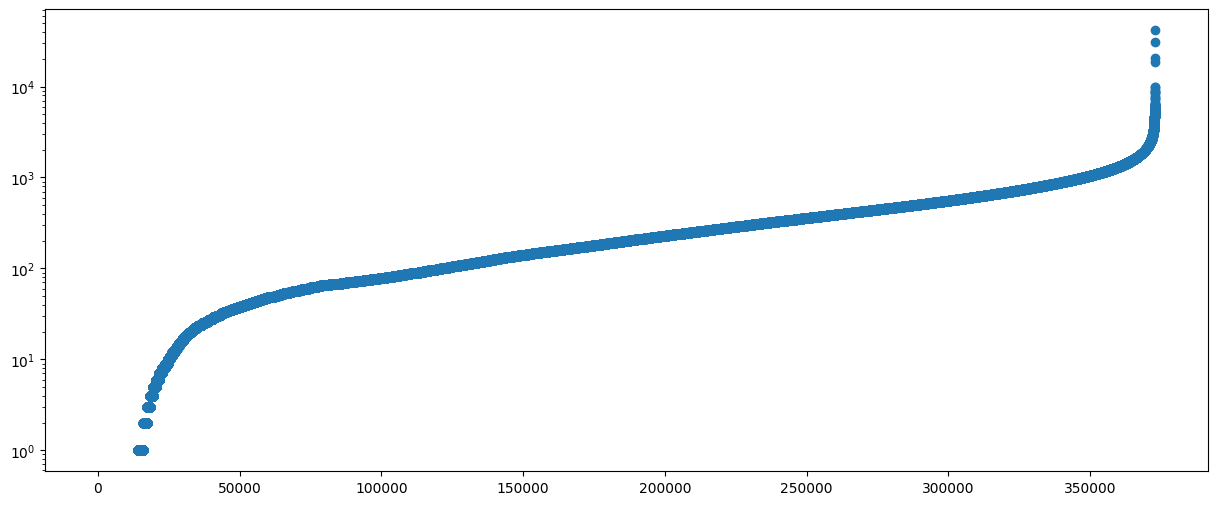

In [4]:
plt.figure(figsize=(15, 6))
plt.plot(sorted(data_demo['session_length'].values), 'o')
plt.yscale('log')
plt.show()

In [5]:
data_demo_filtred = data_demo[(data_demo['session_length']>10) & (data_demo['session_length']<10_000)]

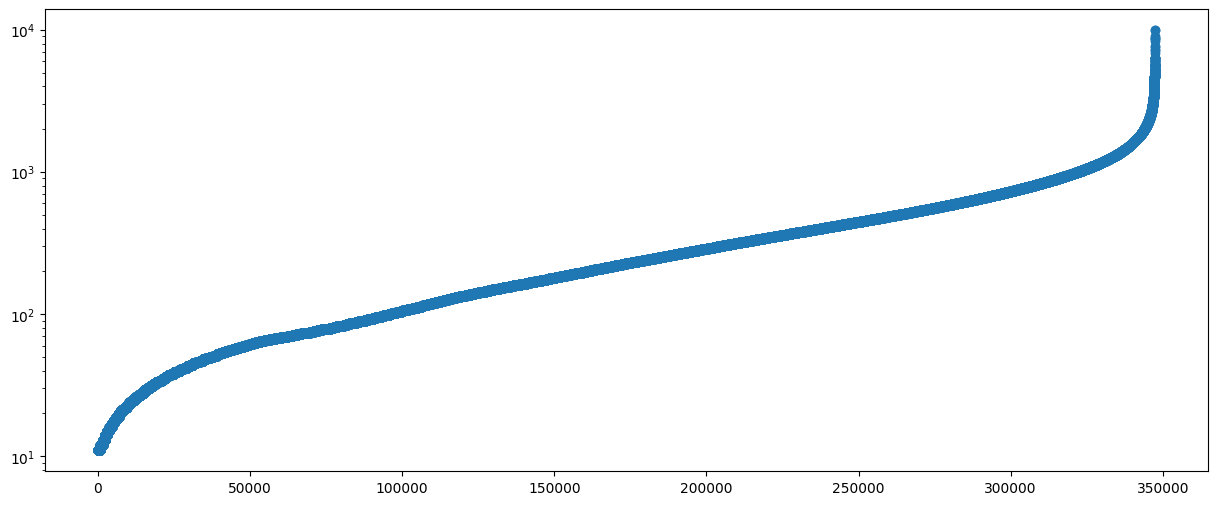

In [6]:
plt.figure(figsize=(15, 6))
plt.plot(sorted(data_demo_filtred['session_length'].values), 'o')
plt.yscale('log')
plt.show()

Nombre de doublons : 246765
  ab_cohort_name  user_count
0          xxLow       16960
1           xLow       16853
2          xHigh       16800
3       gameTune       16752
4         xxHigh       16631
5        control       16608


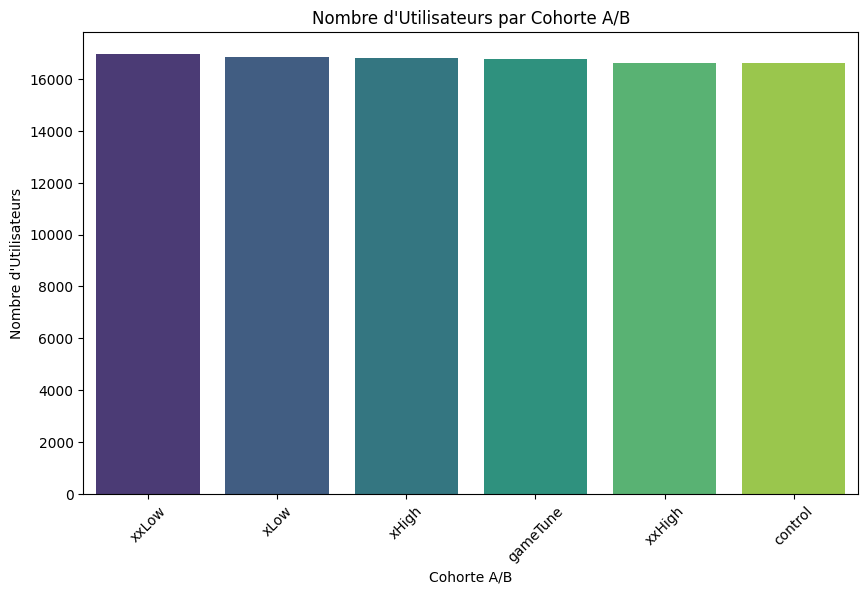

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charger les données avec gestion des erreurs
# Charger les données
file_path = 'C:\\Users\\marye\\Downloads\\Business_Case (1).csv'  # Chemin vers votre fichier CSV
data = pd.read_csv(file_path, delimiter=';')

# Filtrer les données pour garder les sessions entre 10 et 10 000
data_demo_filtred = data[(data['session_length'] > 10) & (data['session_length'] < 10_000)]

# Vérifier le nombre de doublons avant suppression
print(f'Nombre de doublons : {data_demo_filtred.duplicated(subset="user_id").sum()}')

# Supprimer les doublons basés sur user_id
unique_users = data_demo_filtred.drop_duplicates(subset='user_id')

# Compter le nombre d'ab_cohort_name pour chaque user_id unique
cohort_counts = unique_users['ab_cohort_name'].value_counts()

# Convertir en DataFrame pour une manipulation plus facile
cohort_counts_df = cohort_counts.reset_index()
cohort_counts_df.columns = ['ab_cohort_name', 'user_count']

# Afficher le DataFrame des résultats
print(cohort_counts_df)

# Visualiser la distribution des utilisateurs par cohorte
plt.figure(figsize=(10, 6))
sns.barplot(data=cohort_counts_df, x='ab_cohort_name', y='user_count', palette='viridis',hue='ab_cohort_name')  # Choisir une palette de couleurs
plt.title('Nombre d\'Utilisateurs par Cohorte A/B')
plt.xlabel('Cohorte A/B')
plt.ylabel('Nombre d\'Utilisateurs')
plt.xticks(rotation=45)
plt.show()

  ab_cohort_name  avg_revenue_per_session
0        control                 0.034742
1       gameTune                 0.036421
2          xHigh                 0.036997
3           xLow                 0.030695
4         xxHigh                 0.038042
5          xxLow                 0.029403


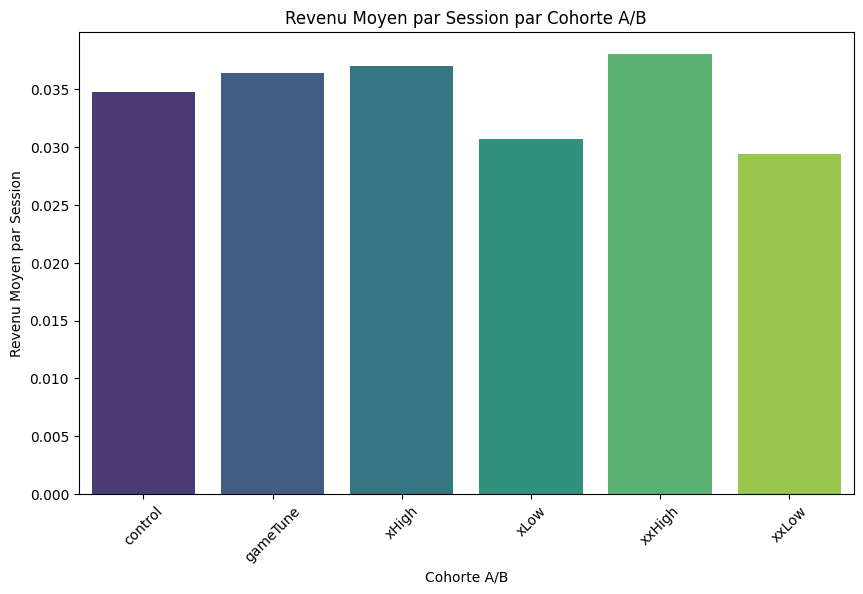

In [16]:
# Calculer le revenu moyen par session pour chaque cohorte
revenue_per_cohort = unique_users.groupby('ab_cohort_name')['publisher_revenue'].mean().reset_index()
revenue_per_cohort.columns = ['ab_cohort_name', 'avg_revenue_per_session']

# Afficher le DataFrame des résultats
print(revenue_per_cohort)

# Visualiser le revenu moyen par cohorte
plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_per_cohort, x='ab_cohort_name', y='avg_revenue_per_session', palette='viridis',hue='ab_cohort_name')
plt.title('Revenu Moyen par Session par Cohorte A/B')
plt.xlabel('Cohorte A/B')
plt.ylabel('Revenu Moyen par Session')
plt.xticks(rotation=45)
plt.show()


  ab_cohort_name  avg_session_length  avg_sessions_per_user
0        control          294.866149               3.530949
1       gameTune          292.367299               3.403713
2          xHigh          302.929345               3.435774
3           xLow          311.230345               3.458375
4         xxHigh          288.870543               3.421803
5          xxLow          315.546875               3.466686


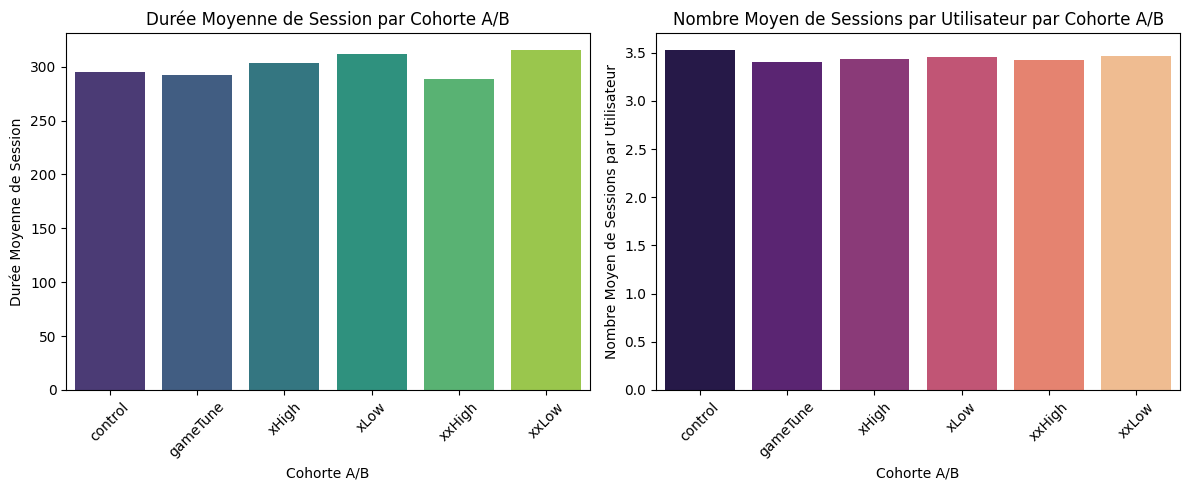

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suppression des doublons basés sur user_id
unique_users = data_demo_filtred.drop_duplicates(subset='user_id')

# Calcul de la durée moyenne de session pour chaque cohorte
avg_session_duration = unique_users.groupby('ab_cohort_name')['session_length'].mean().reset_index()
avg_session_duration.columns = ['ab_cohort_name', 'avg_session_length']

# Calcul du nombre moyen de sessions par utilisateur pour chaque cohorte
sessions_per_user = data_demo_filtred.groupby('ab_cohort_name')['user_id'].nunique().reset_index()
total_sessions = data_demo_filtred.groupby('ab_cohort_name')['session_id'].count().reset_index()
sessions_per_user['avg_sessions_per_user'] = total_sessions['session_id'] / sessions_per_user['user_id']

# Fusionner les résultats pour avoir un DataFrame final
user_experience_df = avg_session_duration.merge(sessions_per_user[['ab_cohort_name', 'avg_sessions_per_user']], on='ab_cohort_name')

# Afficher le DataFrame des résultats
print(user_experience_df)

# Visualiser la durée de session moyenne par cohorte
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=user_experience_df, x='ab_cohort_name', y='avg_session_length', palette='viridis',hue='ab_cohort_name')
plt.title('Durée Moyenne de Session par Cohorte A/B')
plt.xlabel('Cohorte A/B')
plt.ylabel('Durée Moyenne de Session')
plt.xticks(rotation=45)

# Visualiser le nombre moyen de sessions par utilisateur par cohorte
plt.subplot(1, 2, 2)
sns.barplot(data=user_experience_df, x='ab_cohort_name', y='avg_sessions_per_user', palette='magma',hue='ab_cohort_name')
plt.title('Nombre Moyen de Sessions par Utilisateur par Cohorte A/B')
plt.xlabel('Cohorte A/B')
plt.ylabel('Nombre Moyen de Sessions par Utilisateur')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


C:\Users\marye\AppData\Local\Temp\ipykernel_46876\116174733.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=user_retention_per_cohort, x='ab_cohort_name', y='user_retention_count', palette='viridis')


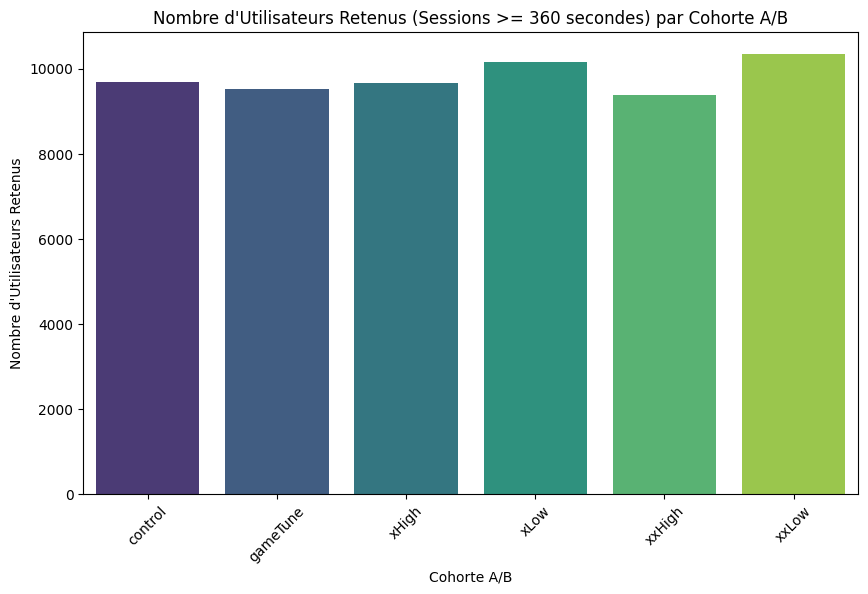

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrer les sessions avec une durée de session supérieure ou égale à 360 secondes
long_sessions = data_demo[data_demo['session_length'] >= 360]

# Compter le nombre d'utilisateurs uniques pour chaque cohorte
user_retention_per_cohort = long_sessions.groupby('ab_cohort_name')['user_id'].nunique().reset_index()
user_retention_per_cohort.columns = ['ab_cohort_name', 'user_retention_count']

# Visualiser le nombre d'utilisateurs retenus par cohorte
plt.figure(figsize=(10, 6))
sns.barplot(data=user_retention_per_cohort, x='ab_cohort_name', y='user_retention_count', palette='viridis')
plt.title('Nombre d\'Utilisateurs Retenus (Sessions >= 360 secondes) par Cohorte A/B')
plt.xlabel('Cohorte A/B')
plt.ylabel('Nombre d\'Utilisateurs Retenus')
plt.xticks(rotation=45)
plt.show()


C:\Users\marye\AppData\Local\Temp\ipykernel_46876\323573549.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=user_retention_per_cohort, x='ab_cohort_name', y='user_retention_count', palette='viridis')


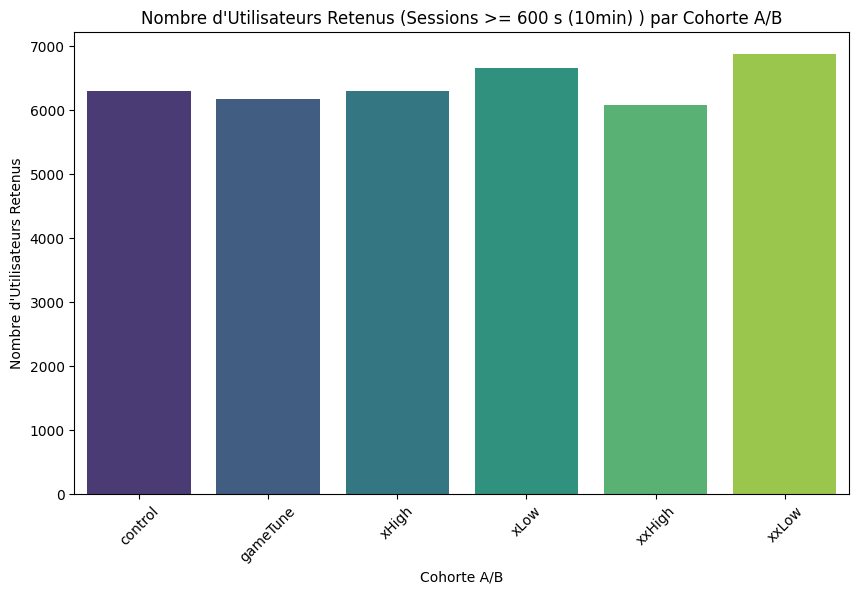

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrer les sessions avec une durée de session supérieure ou égale à 360 secondes
long_sessions = data_demo[data_demo['session_length'] >= 600]

# Compter le nombre d'utilisateurs uniques pour chaque cohorte
user_retention_per_cohort = long_sessions.groupby('ab_cohort_name')['user_id'].nunique().reset_index()
user_retention_per_cohort.columns = ['ab_cohort_name', 'user_retention_count']

# Visualiser le nombre d'utilisateurs retenus par cohorte
plt.figure(figsize=(10, 6))
sns.barplot(data=user_retention_per_cohort, x='ab_cohort_name', y='user_retention_count', palette='viridis')
plt.title('Nombre d\'Utilisateurs Retenus (Sessions >= 600 s (10min) ) par Cohorte A/B')
plt.xlabel('Cohorte A/B')
plt.ylabel('Nombre d\'Utilisateurs Retenus')
plt.xticks(rotation=45)
plt.show()


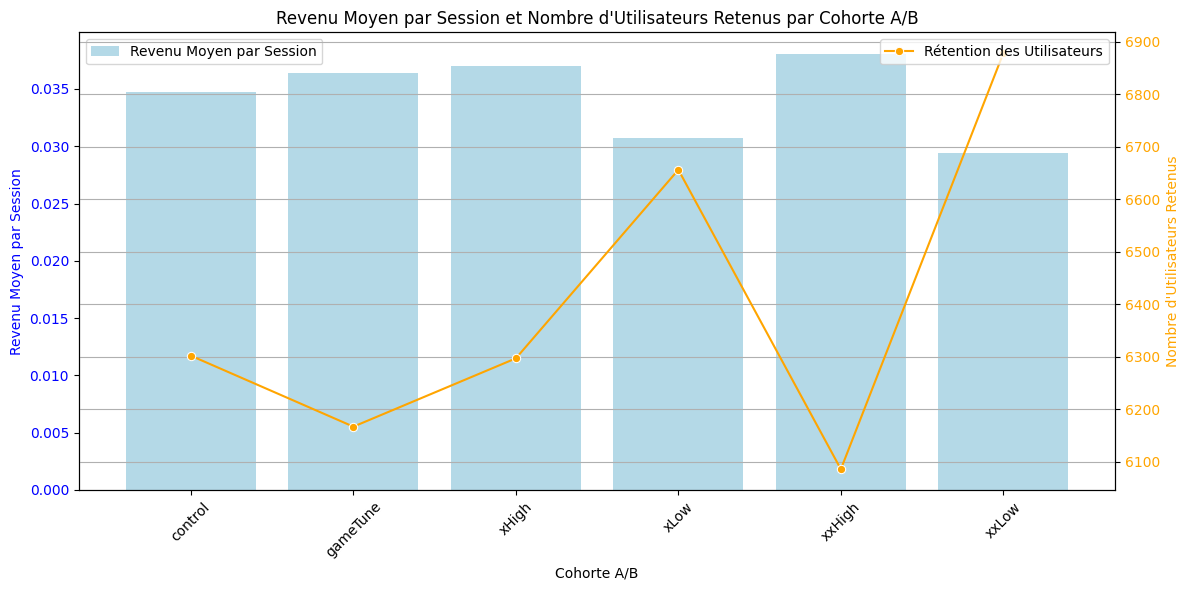

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculer le revenu moyen par session pour chaque cohorte
revenue_per_cohort = unique_users.groupby('ab_cohort_name')['publisher_revenue'].mean().reset_index()
revenue_per_cohort.columns = ['ab_cohort_name', 'avg_revenue_per_session']

# Filtrer les sessions avec une durée de session supérieure ou égale à 360 secondes
long_sessions = data_demo[data_demo['session_length'] >= 600]

# Compter le nombre d'utilisateurs uniques pour chaque cohorte
user_retention_per_cohort = long_sessions.groupby('ab_cohort_name')['user_id'].nunique().reset_index()
user_retention_per_cohort.columns = ['ab_cohort_name', 'user_retention_count']

# Fusionner les deux DataFrames sur 'ab_cohort_name'
combined_data = pd.merge(revenue_per_cohort, user_retention_per_cohort, on='ab_cohort_name')

# Visualiser le revenu moyen et la rétention par cohorte
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barres pour le revenu moyen par session
sns.barplot(data=combined_data, x='ab_cohort_name', y='avg_revenue_per_session', 
            ax=ax1, color='skyblue', label='Revenu Moyen par Session', alpha=0.7)
ax1.set_ylabel('Revenu Moyen par Session', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Créer un second axe pour le nombre d'utilisateurs retenus
ax2 = ax1.twinx()
sns.lineplot(data=combined_data, x='ab_cohort_name', y='user_retention_count', 
             color='orange', marker='o', ax=ax2, label='Rétention des Utilisateurs')
ax2.set_ylabel("Nombre d'Utilisateurs Retenus", color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Ajouter des titres et ajuster les éléments du graphique
plt.title('Revenu Moyen par Session et Nombre d\'Utilisateurs Retenus par Cohorte A/B')
ax1.set_xlabel('Cohorte A/B')
ax1.set_xticks(range(len(combined_data['ab_cohort_name'])))  # Définir les positions fixes
ax1.set_xticklabels(combined_data['ab_cohort_name'], rotation=45)  # Appliquer les étiquettes
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ajout de la colonne 'revenue_metric' dans le DataFrame
data_demo['revenue_metric'] = data_demo['publisher_revenue'] * data_demo['session_length']

# Calcul des statistiques descriptives de la colonne 'revenue_metric'
mean_metric = data_demo['revenue_metric'].mean()
median_metric = data_demo['revenue_metric'].median()
quartiles_metric = data_demo['revenue_metric'].quantile([0.25, 0.5, 0.75])
max_metric = data_demo['revenue_metric'].max()
min_metric = data_demo['revenue_metric'].min()

# Affichage des résultats
print(f"Moyenne de la métrique : {mean_metric}")
print(f"Médiane de la métrique : {median_metric}")
print(f"Quartiles de la métrique :\n{quartiles_metric}")
print(f"Valeur maximale de la métrique : {max_metric}")
print(f"Valeur minimale de la métrique : {min_metric}")



Moyenne de la métrique : 27.70169245999501
Médiane de la métrique : 3.03024126
Quartiles de la métrique :
0.25     0.107091
0.50     3.030241
0.75    19.241963
Name: revenue_metric, dtype: float64
Valeur maximale de la métrique : 12750.051694143009
Valeur minimale de la métrique : 0.0
